In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [2]:

# Charger l'image en niveaux de gris
image = cv2.imread("blue_simple.png", cv2.IMREAD_GRAYSCALE)
image

array([[44, 44, 44, ..., 44, 44, 44],
       [44, 44, 44, ..., 44, 44, 44],
       [44, 44, 44, ..., 44, 44, 44],
       ...,
       [44, 44, 44, ..., 44, 44, 44],
       [44, 44, 44, ..., 44, 44, 44],
       [44, 44, 44, ..., 44, 44, 44]], dtype=uint8)

In [3]:
# Appliquer la transformée de Fourier rapide (FFT)
fft_result = np.fft.fft2(image)  # Calcul de la FFT 2D
fft_shifted = np.fft.fftshift(fft_result)  # Déplacer les basses fréquences au centre


In [4]:

# Calculer la magnitude spectrale
magnitude_spectrum = np.abs(fft_shifted)

# Appliquer l'échelle logarithmique
log_magnitude = np.log1p(magnitude_spectrum)  # log(1 + |F(u,v)|)


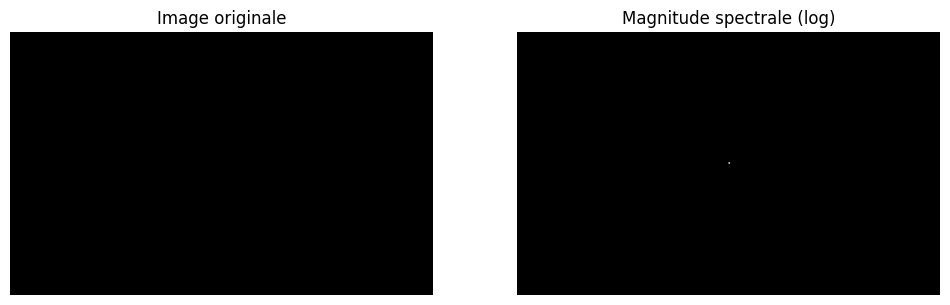

In [5]:

# Afficher l'image originale et la magnitude spectrale
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Image originale")
plt.imshow(image, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Magnitude spectrale (log)")
plt.imshow(log_magnitude, cmap="gray")
plt.axis("off")

plt.show()


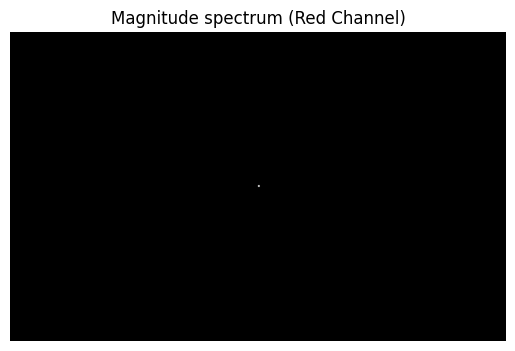

In [6]:
channels = cv2.split(image)           # Split into R, G, B channels

# Process each channel separately
fft_channels = [np.fft.fftshift(np.fft.fft2(ch)) for ch in channels]
magnitude_channels = [np.log1p(np.abs(ch)) for ch in fft_channels]

# Display results (e.g., for the red channel)
plt.imshow(magnitude_channels[0], cmap='gray')
plt.title('Magnitude spectrum (Red Channel)')
plt.axis('off')
plt.show()